# MFA Analysis

Visualizes intrinsic dimensions, Gaussian overlap, and learned MFA subspaces.

In [11]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

experiment_name = os.environ.get("DALG_VIS_EXPERIMENT_NAME", "layer05_1000_394_component_sharded_mfa")
OUT = Path(os.environ.get(
    "DALG_VIS_OUT",
    f"/u/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/pile_gemma2b_models/{experiment_name}",
))
PLOT_OUT = OUT / "plot"
PLOT_OUT.mkdir(exist_ok=True)

dims_data = torch.load(OUT / "intrinsic_dims.pt", weights_only=False)
ov_data   = torch.load(OUT / "gaussian_overlap.pt", weights_only=False)

cluster_sizes  = dims_data["cluster_sizes"]    # (K,)
min_cluster_size = int(os.environ.get("DALG_VIS_MIN_CLUSTER_SIZE", "1000"))
mask = ~(cluster_sizes < min_cluster_size)
max_components = int(os.environ.get("DALG_VIS_MAX_COMPONENTS", "0") or "0")
if max_components > 0 and int(mask.sum().item()) > max_components:
    candidates = torch.nonzero(mask, as_tuple=False).flatten()
    selected = candidates[torch.topk(cluster_sizes[candidates], k=max_components).indices].sort().values
    sampled_mask = torch.zeros_like(mask, dtype=torch.bool)
    sampled_mask[selected] = True
    print(f"Visualization restricted to top {max_components} clusters by size "
          f"out of {int(mask.sum().item())} clusters with size >= {min_cluster_size}")
    mask = sampled_mask
variance_mask = mask.clone()
for idx, (v, keep) in enumerate(zip(dims_data["cluster_variances"], mask.detach().cpu().tolist())):
    if keep and v.numel() == 0:
        variance_mask[idx] = False
if int(variance_mask.sum().item()) < int(mask.sum().item()):
    print(f"Excluded {int(mask.sum().item() - variance_mask.sum().item())} clusters with empty variance spectra")
mask = variance_mask

intrinsic_dims = dims_data["intrinsic_dims"][mask]   # (K,)
selected_variances = [v[:1000] for v, keep in zip(dims_data["cluster_variances"], mask.detach().cpu().tolist()) if keep]
variance_plot_dims = max(v.numel() for v in selected_variances)
cluster_variances = torch.stack([
    torch.cat([v, v.new_zeros(variance_plot_dims - v.numel())]) if v.numel() < variance_plot_dims else v
    for v in selected_variances
])
K     = dims_data["K"]
rank  = dims_data["rank"]
D     = dims_data["D"]
thr   = dims_data["variance_threshold"]

kl_sym  = ov_data["kl_sym"][mask][:,mask]   # (K, K)
db      = ov_data["db"][mask][:,mask]
db_mean = ov_data["db_mean"][mask][:,mask]
db_cov  = ov_data["db_cov"][mask][:,mask]
bc      = ov_data["bc"][mask][:,mask]

# Upper-triangle flat arrays (off-diagonal pairs)
effective_K = mask.sum().item()
idx_i, idx_j = torch.triu_indices(effective_K, effective_K, offset=1)
kl_flat  = kl_sym[idx_i, idx_j]
db_flat  = db[idx_i, idx_j]
dbm_flat = db_mean[idx_i, idx_j]
dbc_flat = db_cov[idx_i, idx_j]
bc_flat  = bc[idx_i, idx_j]

valid = intrinsic_dims > 0
print(f"K={K}  rank(q)={rank}  D={D}  variance_threshold={thr}")
print(f"Clusters with data: {valid.sum().item()} / {K}")
print(f"Intrinsic dim — mean={intrinsic_dims[valid].float().mean():.1f}  "
      f"median={intrinsic_dims[valid].float().median():.1f}  "
      f"min={intrinsic_dims[valid].min().item()}  max={intrinsic_dims[valid].max().item()}")

Excluded 15 clusters with empty variance spectra
K=1000  rank(q)=394  D=2048  variance_threshold=0.9
Clusters with data: 606 / 1000
Intrinsic dim — mean=254.2  median=259.0  min=16  max=553


## 1. Intrinsic Dimensionality

In [12]:
# --- Preprocess ---
cumsum_vars = (cluster_variances.cumsum(dim=1) / 
 cluster_variances.sum(dim=1, keepdim=True)).mean(dim=0) # (K, D) cumulative variance ratios


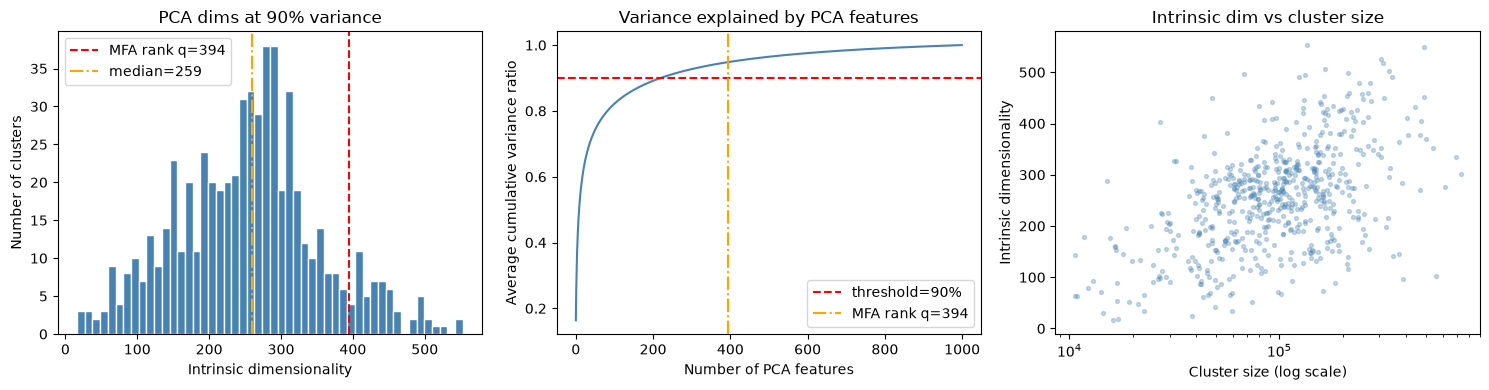

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Histogram of intrinsic dims ---
ax = axes[0]
vals_id = intrinsic_dims.numpy()
ax.hist(vals_id, bins=50, color="steelblue", edgecolor="white")
ax.axvline(rank, color="red", linestyle="--", label=f"MFA rank q={rank}")
ax.axvline(float(np.median(vals_id)), color="orange", linestyle="-.", label=f"median={np.median(vals_id):.0f}")
ax.set_xlabel("Intrinsic dimensionality")
ax.set_ylabel("Number of clusters")
ax.set_title(f"PCA dims at {thr*100:.0f}% variance")
ax.legend()

# --- Variance Explained by features ---
ax = axes[1]
vals = cumsum_vars.numpy()
ax.plot(vals, color="steelblue")
ax.axhline(thr, color="red", linestyle="--", label=f"threshold={thr*100:.0f}%")
ax.axvline(rank, color="orange", linestyle="-.", label=f"MFA rank q={rank}")
ax.set_xlabel("Number of PCA features")
ax.set_ylabel("Average cumulative variance ratio")
ax.set_title("Variance explained by PCA features")
ax.legend()
# --- Intrinsic dim vs cluster size ---
ax = axes[2]
sizes = cluster_sizes[mask].numpy()
ax.scatter(sizes, vals_id, alpha=0.3, s=8, color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Cluster size (log scale)")
ax.set_ylabel("Intrinsic dimensionality")
ax.set_title("Intrinsic dim vs cluster size")

plt.tight_layout()
plt.savefig(PLOT_OUT / f"{experiment_name}_intrinsic_dims.pdf", dpi=150, bbox_inches="tight")
plt.show()

## 2. Cluster Size Distribution

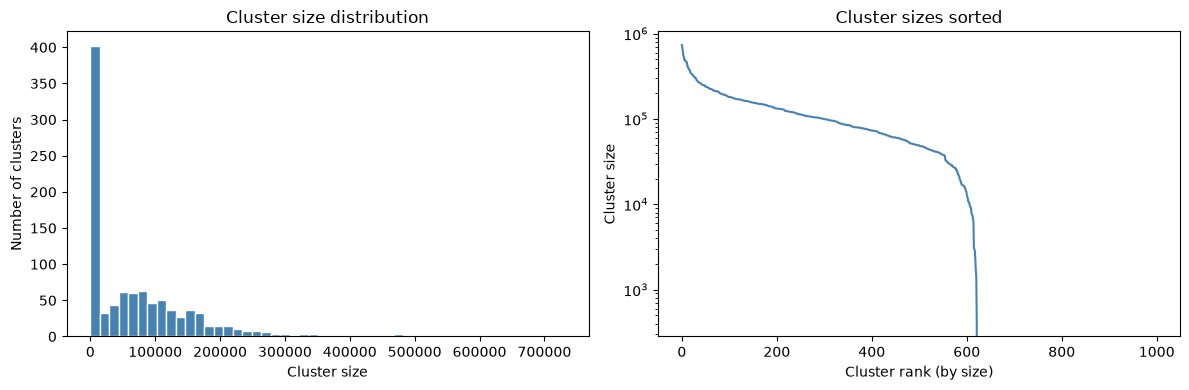

Cluster sizes — min=0  max=731406  mean=73687.9  median=48763.0
Empty clusters: 378


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(cluster_sizes.numpy(), bins=50, color="steelblue", edgecolor="white")
ax.set_xlabel("Cluster size")
ax.set_ylabel("Number of clusters")
ax.set_title("Cluster size distribution")

ax = axes[1]
sorted_sizes = np.sort(cluster_sizes.numpy())[::-1]
ax.plot(sorted_sizes, color="steelblue")
ax.set_xlabel("Cluster rank (by size)")
ax.set_ylabel("Cluster size")
ax.set_title("Cluster sizes sorted")
ax.set_yscale("log")

plt.tight_layout()
plt.savefig(PLOT_OUT / f"{experiment_name}_cluster_sizes.pdf", dpi=150, bbox_inches="tight")
plt.show()

print(f"Cluster sizes — min={cluster_sizes.min().item()}  max={cluster_sizes.max().item()}  "
      f"mean={cluster_sizes.float().mean():.1f}  median={cluster_sizes.float().median():.1f}")
print(f"Empty clusters: {(cluster_sizes == 0).sum().item()}")

## 3. Gaussian Overlap Metrics — Histograms

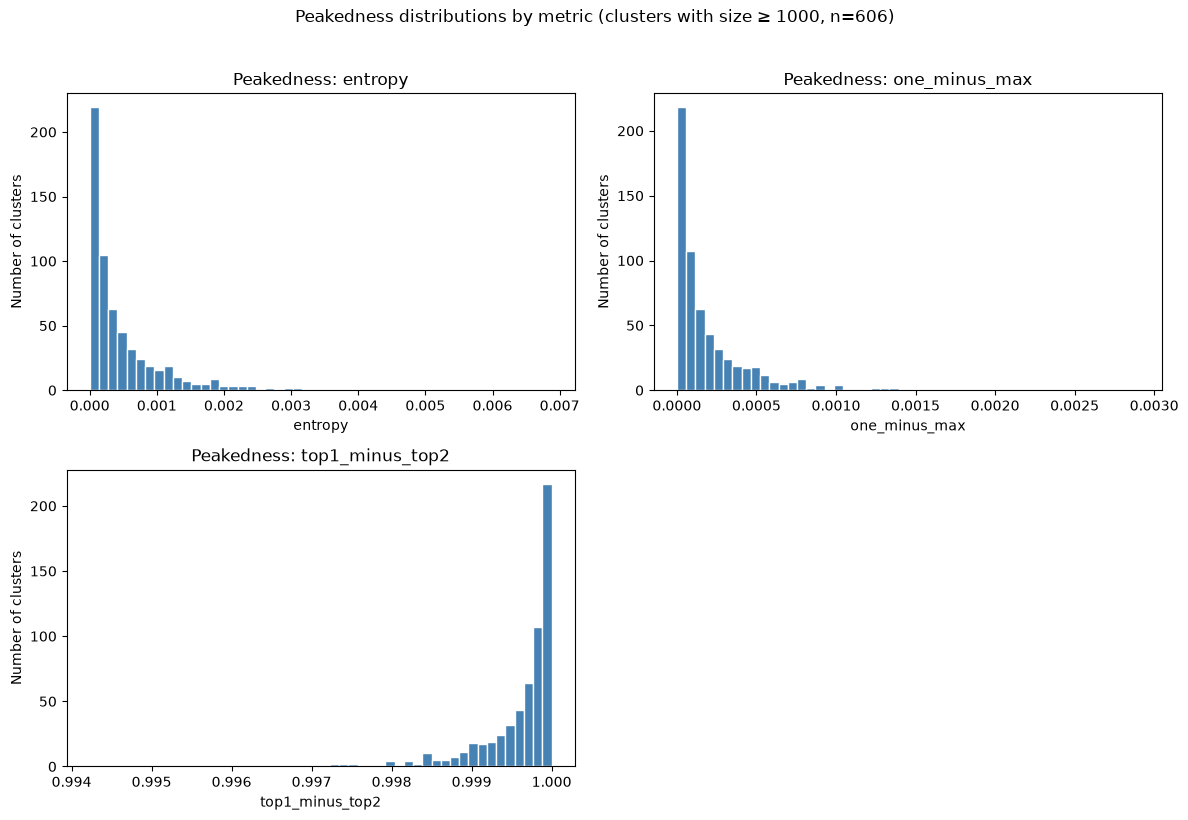

In [15]:
# --- Peakedness of each feature ----
peakedness_dict = dims_data["peakedness"]
metric_names = list(peakedness_dict.keys())

n_metrics = len(metric_names)
n_cols = 2
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax_i, metric_name in enumerate(metric_names):
    values = peakedness_dict[metric_name][mask].detach().cpu().numpy()
    axes[ax_i].hist(values, bins=50, color="steelblue", edgecolor="white")
    axes[ax_i].set_xlabel(metric_name)
    axes[ax_i].set_ylabel("Number of clusters")
    axes[ax_i].set_title(f"Peakedness: {metric_name}")

for ax_i in range(n_metrics, len(axes)):
    axes[ax_i].axis("off")


fig.suptitle(f"Peakedness distributions by metric (clusters with size ≥ 1000, n={effective_K})", y=1.02)
plt.tight_layout()
plt.savefig(PLOT_OUT / f"{experiment_name}_peakedness.pdf", dpi=150, bbox_inches="tight")
plt.show()

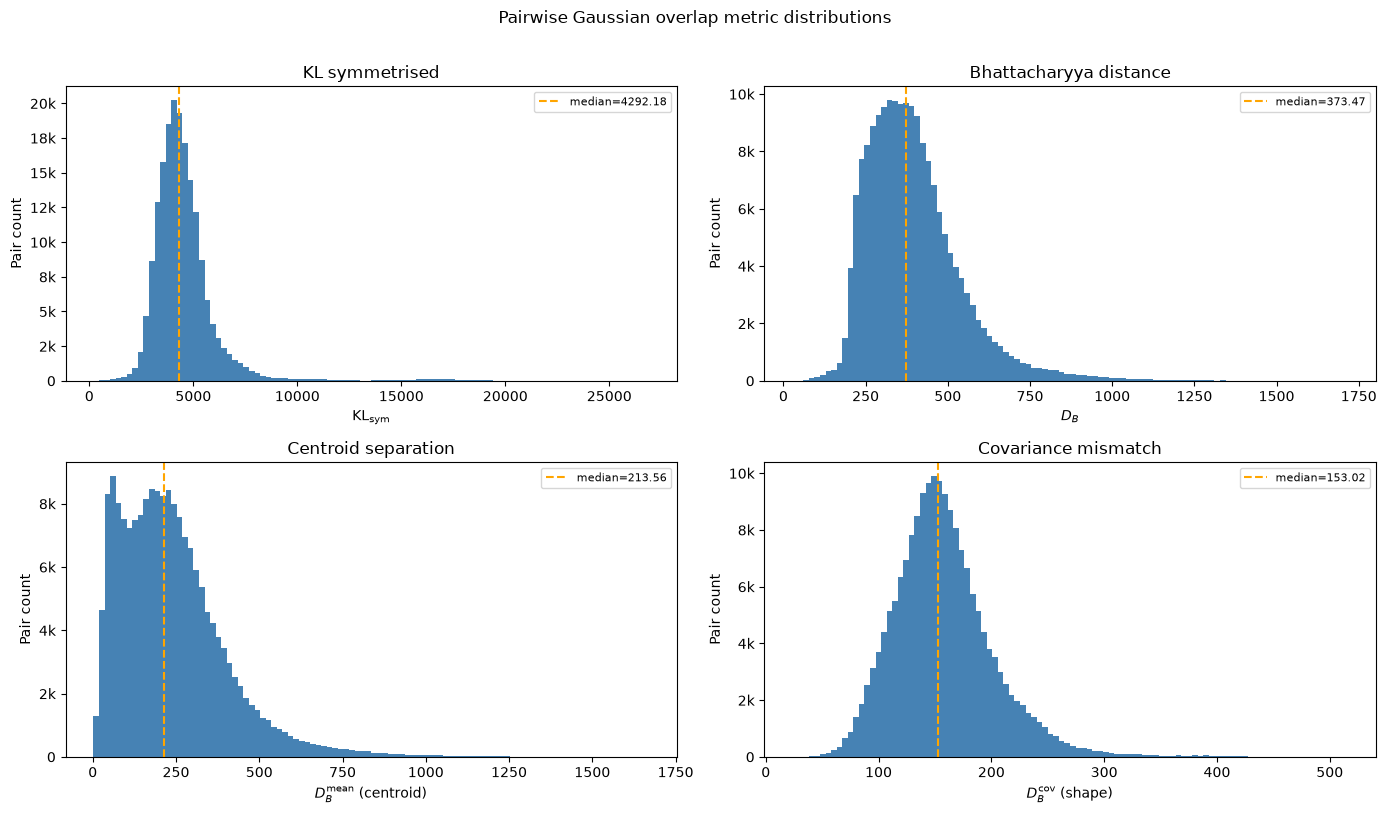

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

panels = [
    (axes[0, 0], kl_flat,  r"$\mathrm{KL}_{\mathrm{sym}}$",      "KL symmetrised"),
    (axes[0, 1], db_flat,  r"$D_B$",                               "Bhattacharyya distance"),
    (axes[1, 0], dbm_flat, r"$D_B^{\mathrm{mean}}$ (centroid)",   "Centroid separation"),
    (axes[1, 1], dbc_flat, r"$D_B^{\mathrm{cov}}$ (shape)",       "Covariance mismatch"),
]

for ax, flat, xlabel, title in panels:
    vals = flat.numpy()
    ax.hist(vals, bins=100, color="steelblue", edgecolor="none")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Pair count")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k" if x >= 1000 else str(int(x))))
    med = float(np.median(vals))
    ax.axvline(med, color="orange", linestyle="--", label=f"median={med:.2f}")
    ax.legend(fontsize=8)

plt.suptitle("Pairwise Gaussian overlap metric distributions", y=1.01)
plt.tight_layout()
plt.savefig(PLOT_OUT / f"{experiment_name}_gaussian_overlap_histograms.pdf", dpi=150, bbox_inches="tight")
plt.show()

## 4. Gaussian Overlap Heatmaps (hierarchically ordered)


In [17]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Order heatmaps by average-linkage clustering on KL_sym, matching the original notebook.
# Clip numerical negatives before converting to scipy's condensed distance format.
kl_np = kl_sym.numpy()
kl_np = np.clip(kl_np, 0, None)
np.fill_diagonal(kl_np, 0)

condensed_raw = squareform(kl_np, checks=False)
positive_kl = condensed_raw[condensed_raw > 0]

condensed = condensed_raw
if positive_kl.size:
    condensed = np.clip(condensed, 0, np.percentile(positive_kl, 99))

Z = linkage(condensed, method="average")
order = leaves_list(Z)

print(f"Hierarchical ordering computed over {effective_K} components")
if positive_kl.size:
    print(
        "Raw KL_sym percentiles: "
        f"50={np.percentile(positive_kl, 50):.2f}, "
        f"90={np.percentile(positive_kl, 90):.2f}, "
        f"99={np.percentile(positive_kl, 99):.2f}"
    )


Hierarchical ordering computed over 606 components
Raw KL_sym percentiles: 50=4292.18, 90=5948.78, 99=13290.58


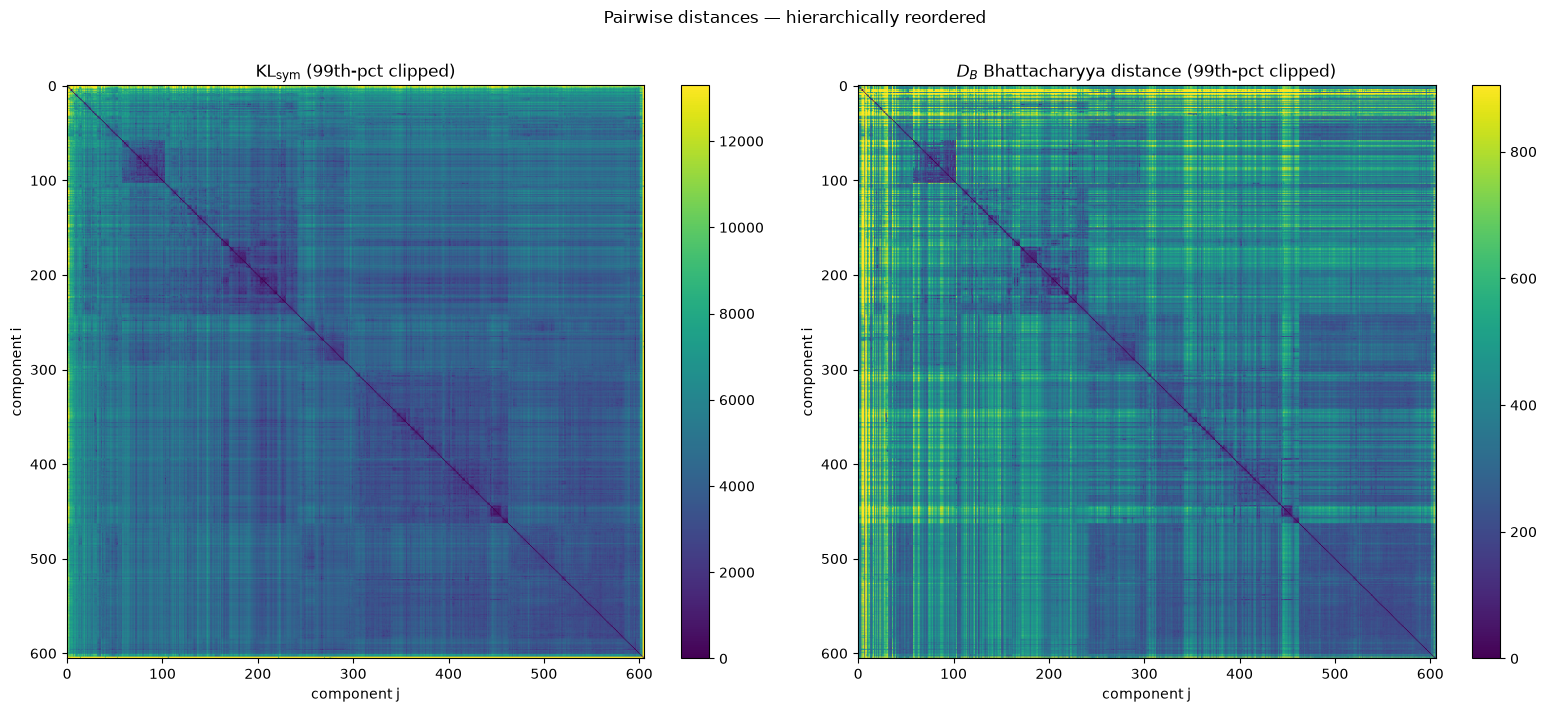

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# TODO I am clipping just the legend it doesn't make sense
# KL_sym heatmap
ax = axes[0]
mat = kl_sym[order][:, order].numpy()
vmax = np.percentile(mat[mat > 0], 99)
im = ax.imshow(mat, aspect="auto", cmap="viridis", vmin=0, vmax=vmax)
ax.set_title(r"$\mathrm{KL}_{\mathrm{sym}}$ (99th-pct clipped)")
ax.set_xlabel("component j")
ax.set_ylabel("component i")
plt.colorbar(im, ax=ax)

# D_B heatmap
ax = axes[1]
mat = db[order][:, order].numpy()
vmax = np.percentile(mat[mat > 0], 99)
im = ax.imshow(mat, aspect="auto", cmap="viridis", vmin=0, vmax=vmax)
ax.set_title(r"$D_B$ Bhattacharyya distance (99th-pct clipped)")
ax.set_xlabel("component j")
ax.set_ylabel("component i")
plt.colorbar(im, ax=ax)

plt.suptitle("Pairwise distances — hierarchically reordered", y=1.01)
plt.tight_layout()
plt.savefig(PLOT_OUT / f"{experiment_name}_gaussian_overlap_heatmaps_dist.pdf", dpi=150, bbox_inches="tight")
plt.show()

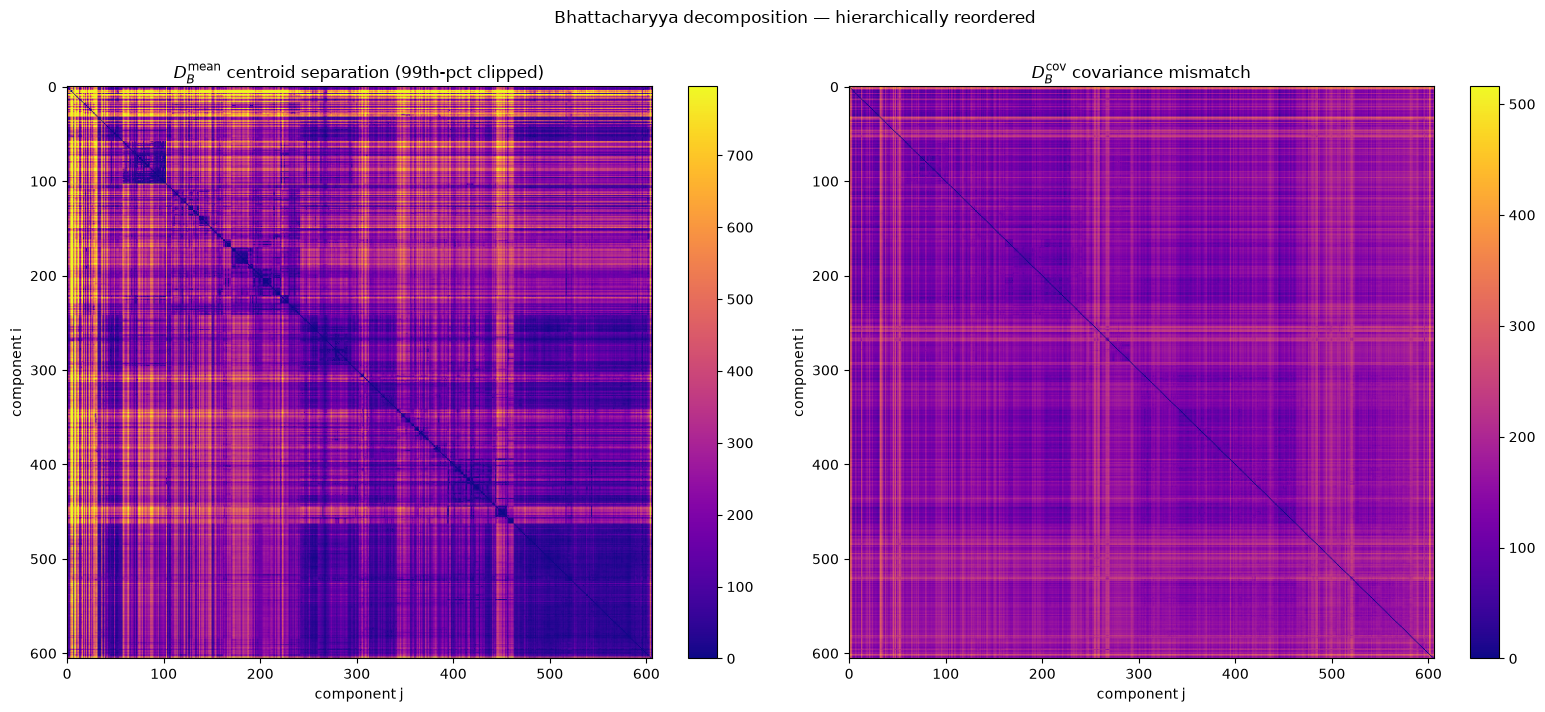

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# TODO I am clipping just the legend it doesn't make sense
# db_mean
ax = axes[0]
mat = db_mean[order][:, order].numpy()
vmax = np.percentile(mat[mat > 0], 99)
im = ax.imshow(mat, aspect="auto", cmap="plasma", vmin=0, vmax=vmax)
ax.set_title(r"$D_B^{\mathrm{mean}}$ centroid separation (99th-pct clipped)")
ax.set_xlabel("component j")
ax.set_ylabel("component i")
plt.colorbar(im, ax=ax)

# db_cov
ax = axes[1]
mat = db_cov[order][:, order].numpy()
im = ax.imshow(mat, aspect="auto", cmap="plasma")
ax.set_title(r"$D_B^{\mathrm{cov}}$ covariance mismatch")
ax.set_xlabel("component j")
ax.set_ylabel("component i")
plt.colorbar(im, ax=ax)

plt.suptitle("Bhattacharyya decomposition — hierarchically reordered", y=1.01)
plt.tight_layout()
plt.savefig(PLOT_OUT / f"{experiment_name}_gaussian_overlap_heatmaps_bhatt.pdf", dpi=150, bbox_inches="tight")
plt.show()

## 5. Where Do the Learned Subspaces W_k Point?

**Experiment.** Each MFA component owns a rank-q loading matrix `W_k` whose
span is its local subspace. We orthonormalize it and compare it with the cached
top-q empirical PCs of the same MFA region. The reference is the
**random-subspace baseline q/D**: a random unit vector has expected squared
projection q/D onto a random q-dimensional subspace.


**Empirical-PC alignment**: compare `span(W_k)` with the cached top-q PCs
of its own MFA region using the mean squared cosine of the principal angles.


For orthonormal bases `Q_i, U_j ∈ R^{D×q}`, the singular values of
`Q_iᵀ U_j` are `cos θ₁, …, cos θ_q`, so
`overlap(i,j) = ‖Q_iᵀ U_j‖²_F / q = mean_l cos² θ_l`. We compare each
component with its own empirical region and with a deterministic wrong-region
pairing as a control.


In [20]:
# Artifacts used only by this MFA subspace analysis.
import gc
import pandas as pd
from IPython.display import Markdown, display

try:
    import plotly.express as px
except Exception as exc:
    px = None
    print(f"Plotly unavailable: {exc}")

MFA_RUN = OUT
Q = int(rank)
MFA_TOP_PCS_PATH = MFA_RUN / "cluster_top_pcs.pt"
HAVE_TOP_PCS = MFA_TOP_PCS_PATH.exists()
top_pcs_mfa_obj = None
pcs_mfa = None
TOP_PCS = 0

if Q == 10:
        
    if HAVE_TOP_PCS:
        top_pcs_mfa_obj = torch.load(
            MFA_TOP_PCS_PATH, map_location="cpu", weights_only=True, mmap=True
        )
        assert int(top_pcs_mfa_obj["K"]) == int(K)
        TOP_PCS = int(top_pcs_mfa_obj["top_pcs"])
        pcs_mfa = top_pcs_mfa_obj["cluster_top_pcs"]
        assert len(pcs_mfa) == int(K)

    COLOR_MFA = "#1baf7a"
    COLOR_NEUTRAL = "#52514e"
    PLOT_TEMPLATE = "plotly_white"


    def save_fig(fig, name: str) -> None:
        fig.update_layout(title_font_size=13, title_x=0.5, margin=dict(t=48))
        pdf_path = PLOT_OUT / f"{experiment_name}_{name}.pdf"
        try:
            fig.write_image(str(pdf_path), width=1000, height=550)
        except Exception as exc:
            html_path = PLOT_OUT / f"{experiment_name}_{name}.html"
            fig.write_html(str(html_path), include_plotlyjs="cdn")
            print(f"PDF export failed ({exc}); saved {html_path.name} instead")

    subspace_df = pd.DataFrame()
    subspace_summary = pd.DataFrame()

    _have_section7_model = (MFA_RUN / "mfa_model.pt").exists() or (MFA_RUN / "mfa_model_shards.json").exists()
    if not (_have_section7_model and HAVE_TOP_PCS and pcs_mfa is not None):
        display(Markdown("**Skipped:** requires the MFA model and MFA cluster_top_pcs.pt."))
    else:
        from dalg.models.mfa import load_mfa as _load_mfa_section7

        # Positive loading scales and the optional invertible factor rotation do
        # not change the column span. QR on dir_raw therefore recovers span(W_k)
        # without constructing another full (K, D, q) loading tensor.
        _model7 = _load_mfa_section7(MFA_RUN / "mfa_model.pt", map_location="cpu")
        assert _model7.K == K and _model7.q == Q
        _q_chunks = []
        with torch.no_grad():
            for _start in range(0, K, 64):
                _dirs = _model7.dir_raw[_start : _start + 64].detach().float()
                _q_chunks.append(torch.linalg.qr(_dirs, mode="reduced")[0].cpu())
        Q_bases = torch.cat(_q_chunks, dim=0)
        del _model7, _q_chunks, _dirs
        gc.collect()

        SUBSPACE_RANK = min(Q, TOP_PCS)
        PCA_D = int(Q_bases.shape[1])
        RANDOM_SUBSPACE_BASELINE = SUBSPACE_RANK / PCA_D
        section7_ids = np.asarray(
            [k for k, basis in enumerate(pcs_mfa) if basis is not None and basis.shape[0] >= SUBSPACE_RANK],
            dtype=int,
        )
        if len(section7_ids) < 2:
            raise RuntimeError("This analysis needs empirical PCA bases for at least two MFA clusters")

        # PCA components are stored row-wise; transpose the first q rows to D x q.
        U_bases = torch.stack(
            [pcs_mfa[int(k)][:SUBSPACE_RANK].T.float() for k in section7_ids], dim=0
        )
        Q_eval = Q_bases[torch.from_numpy(section7_ids), :, :SUBSPACE_RANK]
        _eye = torch.eye(SUBSPACE_RANK)
        raw_pc_basis_max_orth_error = float(
            (torch.matmul(U_bases.transpose(1, 2), U_bases) - _eye).abs().max()
        )
        # The PCA sidecar is numerically close to orthonormal but not exact. QR
        # makes the principal-angle interpretation exact without changing its span.
        U_bases = torch.linalg.qr(U_bases, mode="reduced")[0]
        pc_basis_max_orth_error = float(
            (torch.matmul(U_bases.transpose(1, 2), U_bases) - _eye).abs().max()
        )
        assert pc_basis_max_orth_error < 5e-4, pc_basis_max_orth_error

        same_cross = torch.einsum("kdq,kdr->kqr", Q_eval, U_bases)
        same_cosines = torch.linalg.svdvals(same_cross).clamp_(0.0, 1.0)
        same_overlap = same_cosines.square().mean(dim=1).numpy()
        median_angle_deg = torch.rad2deg(torch.acos(same_cosines)).median(dim=1).values.numpy()

        # One deterministic derangement: every Q_k is paired with another valid U_j.
        _rng7 = np.random.default_rng(0)
        _order = _rng7.permutation(len(section7_ids))
        wrong_index = np.empty(len(section7_ids), dtype=int)
        wrong_index[_order] = np.roll(_order, -1)
        assert np.all(wrong_index != np.arange(len(section7_ids)))
        wrong_cross = torch.einsum("kdq,kdr->kqr", Q_eval, U_bases[wrong_index])
        wrong_overlap = torch.linalg.svdvals(wrong_cross).square().mean(dim=1).numpy()

        subspace_df = pd.DataFrame(
            {
                "cluster": section7_ids,
                "overlap": same_overlap,
                "median_principal_angle_deg": median_angle_deg,
                "wrong_cluster": section7_ids[wrong_index],
                "wrong_cluster_overlap": wrong_overlap,
            }
        )

        def _section7_summary_row(metric: str, values: np.ndarray) -> dict:
            values = np.asarray(values, dtype=float)
            values = values[np.isfinite(values)]
            return {
                "metric": metric,
                "n": len(values),
                "mean": float(np.mean(values)),
                "p10": float(np.quantile(values, 0.1)),
                "median": float(np.median(values)),
                "p90": float(np.quantile(values, 0.9)),
            }

        subspace_summary = pd.DataFrame(
            [
                _section7_summary_row("span(W_k) vs own MFA-region top-q PCs", same_overlap),
                _section7_summary_row("span(W_k) vs wrong MFA-region top-q PCs", wrong_overlap),
                _section7_summary_row("median principal angle (degrees)", median_angle_deg),
            ]
        )
        display(subspace_summary)
        print(
            f"valid MFA PCA clusters: {len(section7_ids)}/{K}; rank={SUBSPACE_RANK}; D={PCA_D}; "
            f"random-subspace overlap q/D={RANDOM_SUBSPACE_BASELINE:.6f}; "
            f"PCA orthonormality error raw={raw_pc_basis_max_orth_error:.2e}, after QR={pc_basis_max_orth_error:.2e}"
        )
        print(f"PCA assignment provenance: {top_pcs_mfa_obj.get('assignments_path', 'not recorded')}")

        if px is not None:
            _overlap_long = pd.DataFrame(
                {
                    "overlap": np.concatenate([same_overlap, wrong_overlap]),
                    "pairing": ["own MFA region"] * len(same_overlap) + ["wrong MFA region"] * len(wrong_overlap),
                }
            )
            fig = px.histogram(
                _overlap_long, x="overlap", color="pairing", nbins=60, barmode="overlay", opacity=0.65,
                title=f"Learned rank-{SUBSPACE_RANK} subspace vs empirical MFA-region PCs",
                color_discrete_map={"own MFA region": COLOR_MFA, "wrong MFA region": COLOR_NEUTRAL},
                template=PLOT_TEMPLATE,
            )
            fig.add_vline(
                x=RANDOM_SUBSPACE_BASELINE, line_dash="dash", line_color="#0b0b0b",
                annotation_text=f"random q/D ({RANDOM_SUBSPACE_BASELINE:.4f})", annotation_position="top right",
            )
            fig.update_layout(xaxis_title="mean cos² of principal angles", yaxis_title="cluster pairs", bargap=0.05)
            save_fig(fig, "w_empirical_pc_overlap_hist")
            fig.show()
        del Q_bases, Q_eval, U_bases, same_cross, same_cosines, wrong_cross
        gc.collect()


## 6. Effective Rank of the Gaussian Covariances

Each MFA component has covariance

`Σ_k = W_k W_kᵀ + diag(ψ_k)`.

We measure its approximate rank with the spectral participation ratio

`PR(Σ_k) = tr(Σ_k)² / tr(Σ_k²) = (Σ_i λ_i)² / Σ_i λ_i²`.

PR is 1 for a rank-one spectrum and D when all eigenvalues are equal. The
diagonal noise makes every Gaussian covariance algebraically full-rank, so PR
is an effective spectral rank rather than the matrix rank. It is computed
from low-rank trace identities without constructing any D × D covariance.


,components,factor_rank_q,ambient_dim_D,mean_PR,p10_PR,median_PR,p90_PR,min_PR,max_PR
0,1000,394,2048,32.899191,21.667856,27.758997,50.165319,3.296532,203.841812


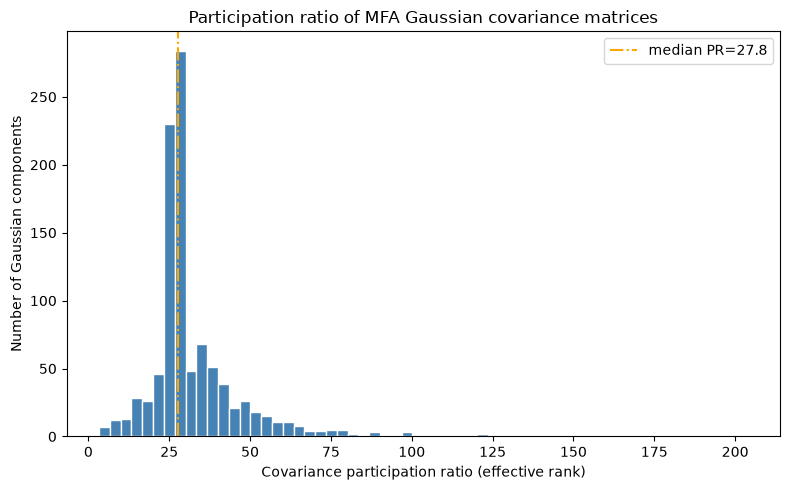

In [21]:
import gc
import pandas as pd
from IPython.display import Markdown, display
from dalg.models.mfa import load_mfa

covariance_pr_df = pd.DataFrame()
covariance_pr_summary = pd.DataFrame()
MFA_MODEL_PATH = OUT / "mfa_model.pt"
HAVE_MFA_MODEL = MFA_MODEL_PATH.exists() or (OUT / "mfa_model_shards.json").exists()

if not HAVE_MFA_MODEL:
    display(Markdown("**Skipped:** requires the MFA model in `OUT`."))
else:
    _pr_model = load_mfa(MFA_MODEL_PATH, map_location="cpu")
    _pr_model.eval()
    assert _pr_model.K == int(K) and _pr_model.D == int(D)

    # For Σ = WWᵀ + Ψ with diagonal Ψ:
    # tr(Σ²) = ||WᵀW||²_F + 2 tr(WWᵀΨ) + tr(Ψ²).
    PR_BATCH_SIZE = 64
    _eps = float(_pr_model._eps)
    _shared_psi = _pr_model.psi_rho.ndim == 1
    _shared_psi_values = None
    if _shared_psi:
        _shared_psi_values = torch.nn.functional.softplus(
            _pr_model.psi_rho.detach()
        ) + _eps

    _pr_chunks = []
    with torch.no_grad():
        for _start in range(0, _pr_model.K, PR_BATCH_SIZE):
            _stop = min(_start + PR_BATCH_SIZE, _pr_model.K)
            _dirs = _pr_model.dir_raw[_start:_stop].detach()
            _dir_norms = _dirs.norm(dim=1, keepdim=True).clamp_min(_eps)
            _scales = torch.nn.functional.softplus(
                _pr_model.scale_rho[_start:_stop].detach()
            )
            # This is the unrotated W used by the Gaussian likelihood.
            _W = (_dirs / _dir_norms) * _scales[:, None, :]
            _w_sq_by_dim = _W.square().sum(dim=-1)

            if _shared_psi:
                _psi = _shared_psi_values[None, :].expand(_stop - _start, -1)
            else:
                _psi = torch.nn.functional.softplus(
                    _pr_model.psi_rho[_start:_stop].detach()
                ) + _eps

            _trace = (
                _w_sq_by_dim.sum(dim=1).double() + _psi.sum(dim=1).double()
            )
            _gram = torch.matmul(_W.transpose(1, 2), _W)
            _trace_sq = (
                _gram.double().square().sum(dim=(1, 2))
                + 2.0 * (_psi * _w_sq_by_dim).sum(dim=1).double()
                + _psi.double().square().sum(dim=1)
            )
            _pr_chunks.append((_trace.square() / _trace_sq).cpu())

    covariance_pr = torch.cat(_pr_chunks).numpy()
    assert np.isfinite(covariance_pr).all()
    assert covariance_pr.min() >= 1.0 - 1e-6
    assert covariance_pr.max() <= int(D) + 1e-3

    covariance_pr_df = pd.DataFrame(
        {
            "component": np.arange(_pr_model.K),
            "participation_ratio": covariance_pr,
            "fraction_of_ambient_dim": covariance_pr / _pr_model.D,
        }
    )
    covariance_pr_summary = pd.DataFrame(
        [
            {
                "components": len(covariance_pr),
                "factor_rank_q": _pr_model.q,
                "ambient_dim_D": _pr_model.D,
                "mean_PR": float(np.mean(covariance_pr)),
                "p10_PR": float(np.quantile(covariance_pr, 0.1)),
                "median_PR": float(np.median(covariance_pr)),
                "p90_PR": float(np.quantile(covariance_pr, 0.9)),
                "min_PR": float(np.min(covariance_pr)),
                "max_PR": float(np.max(covariance_pr)),
            }
        ]
    )
    display(covariance_pr_summary)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(covariance_pr, bins=60, color="steelblue", edgecolor="white")
    ax.axvline(
        float(np.median(covariance_pr)), color="orange", linestyle="-.",
        label=f"median PR={np.median(covariance_pr):.1f}",
    )
    ax.set_xlabel("Covariance participation ratio (effective rank)")
    ax.set_ylabel("Number of Gaussian components")
    ax.set_title("Participation ratio of MFA Gaussian covariance matrices")
    ax.legend()
    plt.tight_layout()
    plt.savefig(
        PLOT_OUT / f"{experiment_name}_gaussian_covariance_participation_ratio.pdf",
        dpi=150, bbox_inches="tight",
    )
    plt.show()

    del _pr_model, _pr_chunks, _dirs, _W, _w_sq_by_dim, _psi, _gram
    gc.collect()
